In [1]:
from caxscripts.image_statistics import Histogram2DAnalyzer as H2DA
from caxscripts.image_statistics import FWHM2SIG
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np
import matplotlib.pyplot as plt

In [30]:
# Nominal parameters:

size_x = 1920
size_y = 1080
max_intensity = 1000
tot_size = size_x*size_y*10
mean = (512, 256)
sigx = 36
sigy = 24
covxy = 32
cov = np.array([[sigx**2, covxy  ],
                [covxy  , sigy**2]])

sig_major, sig_minor, theta, evecs = H2DA._ellipse_params_from_cov(_,
            cov
        )

xcenters = np.arange(0, size_x) + 0.5
ycenters = np.arange(0, size_y) + 0.5

hprm_nominal = {
    "mux"       : mean[0], 
    "muy"       : mean[1],
    "cov"       : cov,
    "sigx"      : sigx, 
    "sigy"      : sigy,
    "fwhmx"     : sigx/FWHM2SIG, 
    "fwhmy"     : sigy/FWHM2SIG,
    "sig_major" : sig_major, 
    "sig_minor" : sig_minor,
    "theta"     : H2DA.adjust_angle(theta), 
    "evecs"     : evecs,
    "xcenters"  : xcenters, 
    "ycenters"  : ycenters,
}

In [31]:
H2DA.print_stats(_, hprm=hprm_nominal)

centroid   = (5.1200e+02, 2.5600e+02)
sigma x    = 3.6000e+01
sigma y    = 2.4000e+01
fwhm x     = 1.5288e+01
fwhm y     = 1.0192e+01
xy cov     = 3.2000e+01

principal sigmas:
    sigma minor = 23.97041042747394
    sigma major = 36.01970882639737

theta = 4.4328e-02 rad = 2.5398e+00 deg

cov matrix:
[[1296   32]
 [  32  576]]


In [32]:
# From these parameters we can draw a histogram of intensities


ana = H2DA.from_gaussian(size=tot_size, 
                         bins=(size_x, size_y), 
                         hist_range=[[0, size_x], [0, size_y]], 
                         mean=mean, 
                         cov=cov)

# ana.img = ana.img  # Scale to match total counts

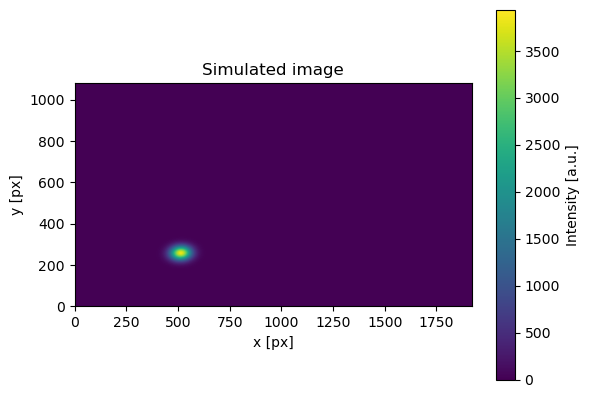

In [33]:
plt.imshow(ana.img.T, origin="lower", extent=[0, size_x, 0, size_y])
plt.xlabel("x [px]")
plt.ylabel("y [px]")
plt.title("Simulated image")
plt.colorbar(label="Intensity [a.u.]")
plt.show()

In [5]:
def plot_projections(ana, img, hprm, xlim, ylim, title=None):
    """Plot the image with the fitted ellipse and respective projections.

    Arguments:
        ana  : Histogram2DAnalyzer instance with the image and parameters.
        img  : image data to plot.
        hprm : dictionary of parameters to plot the ellipse.
        xlim : horizontal limits for the main image plot.
        ylim : vertical limits for the main image plot.
        title : title for the main image plot.
    """
    fig, ax0 = plt.subplots(figsize=(14, 6))

    divider = make_axes_locatable(ax0)
    axb = divider.append_axes("bottom", size="25%", pad=0.3, sharex=ax0)
    axr = divider.append_axes("right", size="25%", pad=0.3, sharey=ax0)

    # Plot the main image with the ellipses (no colorbar to avoid displacement).
    ana.plot(hprm=hprm, fig=fig, ax=ax0, colorbar=False)
    ax0.set_xlim(xlim)
    ax0.set_ylim(ylim)
    if title is not None:
        ax0.set_title(title)

    # Suppress redundant tick labels
    ax0.tick_params(labelbottom=False)
    axr.tick_params(labelleft=False)

    xproj = np.sum(img, axis=0)
    py = np.arange(len(xproj))
    axr.plot(xproj, py, drawstyle='steps-post')

    # axr.axhline(hprm['muy'], color='red', linestyle='--', label='Center Y')

    yproj = np.sum(img, axis=1)
    axb.plot(yproj, drawstyle='steps-post')

    axb.grid(True)
    axr.grid(True)


In [9]:
xlim = (hprm_nominal['mux'] - 5*hprm_nominal['sigx'],
        hprm_nominal['mux'] + 5*hprm_nominal['sigx'])
ylim = (hprm_nominal['muy'] - 5*hprm_nominal['sigy'],
        hprm_nominal['muy'] + 5*hprm_nominal['sigy'])

In [29]:
for i in range(100):
    ana.add_noise(noisetype='poisson' , level=5)
    # ana.img = ana.img - np.min(ana.img)
    # ana.img = np.where(ana.img > np.mean(ana.img), ana.img-np.mean(ana.img), 0)

In [218]:
ana.add_noise(noisetype='gaussian', level=5)


/media/gabriel/AcerD/CNPEM/scripts/image_statistics.py:518: RuntimeWarning: invalid value encountered in sqrt
  loc=0, scale=np.sqrt(self.img), size=self.img.shape


In [223]:
np.min(ana.img)

399.0

In [17]:
ana.img = ana.img - np.min(ana.img)

In [167]:
ana.add_noise(level=50)

In [20]:
img = ana.img.copy()
ana.img = np.where(ana.img > np.mean(img), img-np.mean(img), img)

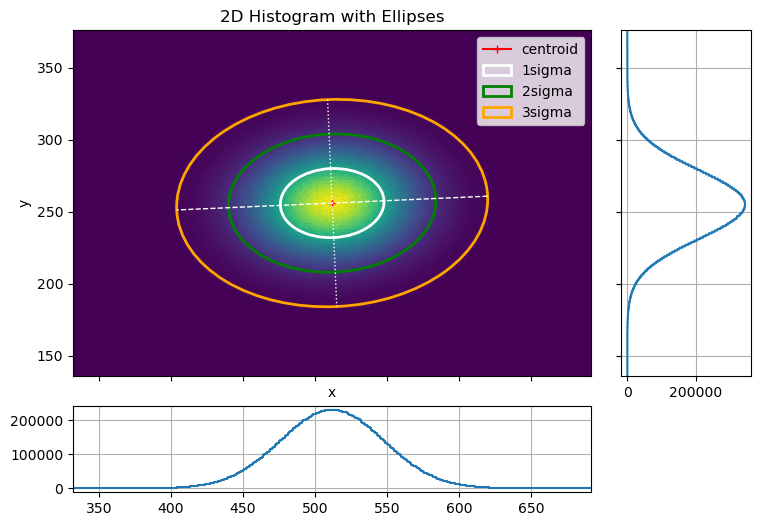

In [10]:
plot_projections(ana, ana.img, hprm_nominal, xlim, ylim)

(136.0, 376.0)

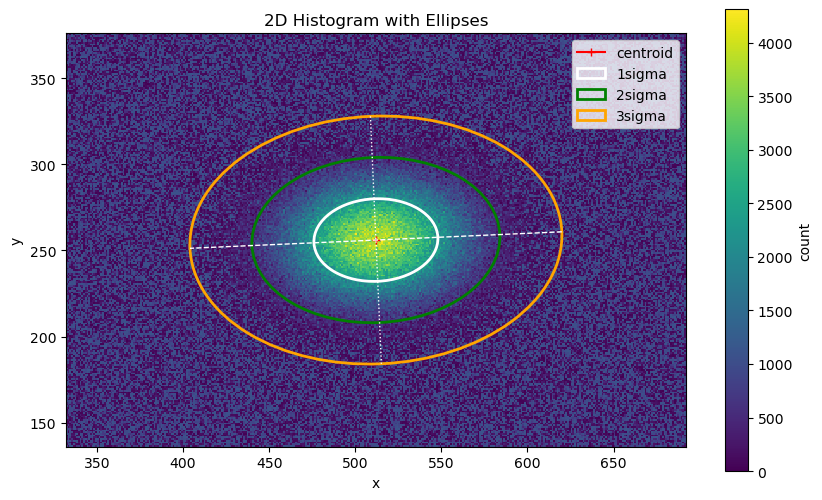

In [21]:
ana.plot(hprm=hprm_nominal)
plt.xlim(xlim)
plt.ylim(ylim)

In [55]:
img = np.ones_like(ana.img)
img = img*np.cos(np.linspace(0, 50, 1080))+1

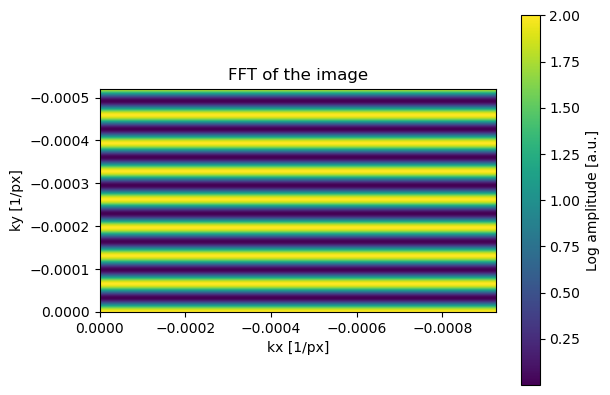

In [65]:
# FFT analysis

fft_img = np.fft.fft2(img)

freq_img = np.fft.fftshift(fft_img)
fx = np.fft.fftfreq(size_x)
fy = np.fft.fftfreq(size_y)
# plt.imshow(np.log(np.abs(freq_img.T)+1), origin="lower")
plt.imshow(img.T, extent=[fy[0], fy[-1], fx[0], fx[-1]], origin="lower")
plt.xlabel("kx [1/px]")
plt.ylabel("ky [1/px]")
plt.title("FFT of the image")
plt.colorbar(label="Log amplitude [a.u.]")
# plt.xlim(0, 10)
plt.show()

In [57]:
np.max(np.abs(fft_img))

2064617.1780372048

In [22]:
# Now we calculate its properties with the 3 methods:
# Beam is not being marked as visible with level above 25 of added noise, 
# although it is clearly there... maybe lower the threshold for visibility?
# I'll keep increasing the noise to the point where it would be hard to
# notice the beam and then evaluate that ratio.

# ana.compute_moments()
# ana.fit(useroi=True)
# ana._qck_centroid()
ana._compute_beam_visibility(*mean)

False

In [24]:
cx, cy = mean
droi = 4
roi_avg = np.mean(
         ana.img[cx - droi:cx + droi, 
             cy - droi:cy + droi]
)
meanish = np.mean(ana.img)
ratio = (roi_avg / meanish) if mean != 0 else 0

print(roi_avg)
print(meanish)
print(ratio)

3800.592733410493
575.3546646856312
6.605652072860319


In [68]:
ana.img[cx - droi:cx + droi, 
             cy - droi:cy + droi]

array([[3790., 3816., 3749., 3820., 3944., 3825., 3794., 3924.],
       [3779., 3778., 3801., 3859., 3741., 3842., 3804., 3920.],
       [3852., 3869., 3754., 3932., 3903., 3867., 3901., 3738.],
       [3733., 3754., 3820., 3938., 3923., 3830., 3854., 3809.],
       [3808., 3966., 3855., 3850., 3904., 3868., 3856., 3869.],
       [3777., 3977., 3808., 3913., 3919., 3807., 3914., 3853.],
       [3949., 3874., 3866., 3736., 3875., 3863., 3917., 3816.],
       [3833., 3869., 3831., 3843., 3852., 3867., 3834., 3818.]])